In [ ]:
#Imports
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath("../src"))
sys.path.append(os.path.abspath("../data"))

import preprocessing as prep
import utils as utls
import data_splitting as data
import models as mdls
import metrics as mtr


In [ ]:
df_raw = pd.read_csv("../data/raw/rendimiento_estudiantes_dev.csv") 
#print(df_raw.sample(15))


## Analisis exploratorio de datos

#### 1.1 Graficos y visualizacion de datos

Histogramas

In [ ]:
df = df_raw.copy()

ord_rend = {
    "Insuficiente": 0,
    "Regular": 1,
    "Bueno": 2, 
    "Excelente": 3
}

ord_sem = {
    "2022-1": 0,
    "2022-2": 1,
    "2023-1": 2,
    "2023-2": 3,
    "2024-1": 4,
    "2024-2": 5
}

df = prep.ordinal_encoding(df, ord_rend, "rendimiento")
df = prep.ordinal_encoding(df, ord_sem, "semestre") # Me importa el orden cronologico, se podrian hacer solo dos columnas de anio y semestre

fig, axes = plt.subplots(5, 3, figsize=(16, 14))
axes = axes.flatten()

cols = df.columns.tolist()  # o listá las columnas manualmente

for i, col in enumerate(cols):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=13)
    axes[i].set_xlabel('')
    axes[i].tick_params(labelsize=10)

# Ocultar subplots vacíos si sobran
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de variables', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

Se puede ver que en escuelas algunos estan en minuscula

Boxplots


In [ ]:
feats = ["horas_estudio","asistencia","nota_previa","horas_sueno","participacion","horas_extracurricular", "distancia_escuela_km","nivel_socioeconomico","tamano_clase"]
utls.boxplots(df, feats)

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, feat in zip(axes.flatten(), feats):
    sns.boxplot(data=df, x='rendimiento', y=feat, ax=ax)
    ax.set_xticks(range(4))
    ax.set_xticklabels(['Insuf', 'Regular', 'Bueno', 'Excelente'])

Mucha cantidad de outliers evidentes en nota previa sugiere que hay notas asignadas de 0 a 100
Muchos outliers en horas extracurricular y distancia escuela

#### Heatmap de correlaciones

In [ ]:
f = feats + ["rendimiento"]

plt.figure(figsize=(10, 8))
sns.heatmap(df[f].corr(), annot=True, fmt='.2f', 
            cmap='coolwarm', center=0)
plt.title("Correlaciones entre features")
plt.tight_layout()
plt.show()

In [ ]:
df['aprobado'] = (df['rendimiento'] != 0).astype(int)


fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=130)

# Multiclase
sns.countplot(data=df, x='rendimiento', ax=axes[0], color='steelblue')
axes[0].set_title('Distribución multiclase', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Cantidad')
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{int(bar.get_height())}', ha='center', fontsize=10)

# Binaria
sns.countplot(data=df, x='aprobado', ax=axes[1], color='steelblue')
axes[1].set_title('Distribución binaria', fontsize=13, fontweight='bold')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Desaprobado (0)', 'Aprobado (1)'])
axes[1].set_xlabel('')
axes[1].set_ylabel('Cantidad')
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{int(bar.get_height())}', ha='center', fontsize=10)

plt.suptitle('Distribución de la variable objetivo', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# distribución binaria
df["aprobado"].value_counts(normalize=True)

# distribución multiclase  
df["rendimiento"].value_counts(normalize=True)

Este grafico demuestra un gran desbalance en la distribucion binaria, dado que aproximadamente mas del 80% de los datos son considerados aprobados. Esto quiere decir que es posible que el modelo usando la clasificacion binaria aprneda a predecir positivo.

In [ ]:
df = prep.school_letters(df)
df = prep.one_hot_encoding(df, "escuela")
df = prep.notes_scale(df)

#### 1.2 Division por escuelas

In [ ]:
feats_numericas = ['horas_estudio', 'asistencia', 'nota_previa', 'horas_sueno',
                   'participacion', 'horas_extracurricular', 'distancia_escuela_km',
                   'nivel_socioeconomico', 'tamano_clase']

label_rend = {v: k for k, v in ord_rend.items()}
label_sem  = {v: k for k, v in ord_sem.items()}


utls.plot_school_analysis(df, feats_numericas, label_rend, label_sem)

En el boxplot de nivel socioeconomico se puede ver que las medianas y rangos de cada escuela son muy diferentes, contra horas de sueno por ejemplo que tiene una distribucion casi identica para todas las escuelas. 

Las mas diferentes son asistencia, nivel socioeconomico, nota previa, tamano clase.

se puede pensar que esto afecta directamente el rendimiento, en D y G el rendimiento es mucho menor que que en C que es casi todo excelente. Se podria inferir que esas features que son las que mas varian por escuela son las razones por las diferencias de rendimientos. 

casi que no hay variacion entre semestres, pero si enormemente entre escuelas.

En cuanto a las correlaciones, se puede ver que si bien los valores absolutos difieren, en todas las escuelas las features con mas correlaciones mas altas con rendimiento (target) son las mismas: horas estudio, nota previa, asistencia, y mas baja pero igual participacion.

#### 1.3 Limpieza e imputacion de datos


DEJAR PARA ESTA PARTE LOS ENCODINGS

Teniendo en cuenta que las distribuciones de ciertas features varian mucho segun escuela, la limpieza de datos como la imputacion de valores faltantes se va a realizar segun escuela. 

## 2. Clasificacion binaria y Estrategias de Splitting

In [ ]:
feats_imp = ["asistencia", "nota_previa", "horas_estudio", "horas_sueno", "participacion", "nivel_socioeconomico"]

# Como cada split tiene un train diferente, se imputa y normaliza dentro de cada uno de ellos
#Split random 80/20
train_set_r, val_set_r = data.random_split(df)
medians_r = prep.medians(train_set_r, feats_imp) #me tengo que guardar los valores con los cuales voy a imputar sobre val y test
train_set_r = prep.impute(train_set_r, medians_r, feats_imp) 
val_set_r = prep.impute(val_set_r, medians_r, feats_imp) 

exclude = ["rendimiento", "aprobado"]
params_r = prep.params_norm(train_set_r, exclude)
train_norm_r = prep.normalize_df(train_set_r, params_r)
val_norm_r = prep.normalize_df(val_set_r, params_r)

# Group split --> Eligo A y G para val ya que tienen distribuciones diferentes de las features (explicar mas)
train_set_g, val_set_g= data.group_split(df, ["A", "G"])
medians_g = prep.medians(train_set_g, feats_imp) #me tengo que guardar los valores con los cuales voy a imputar sobre val y test
train_set_g = prep.impute(train_set_g, medians_g, feats_imp) 
val_set_g = prep.impute(val_set_g, medians_g, feats_imp) 

params_g = prep.params_norm(train_set_g, exclude)
train_norm_g = prep.normalize_df(train_set_g, params_g)
val_norm_g = prep.normalize_df(val_set_g, params_g)

# Temporal split
train_set_t, val_set_t= data.temp_split(df)
medians_t = prep.medians(train_set_t, feats_imp) #me tengo que guardar los valores con los cuales voy a imputar sobre val y test
train_set_t = prep.impute(train_set_t, medians_t, feats_imp) 
val_set_t = prep.impute(val_set_t, medians_t, feats_imp) 

params_t = prep.params_norm(train_set_t, exclude)
train_norm_t = prep.normalize_df(train_set_t, params_t)
val_norm_t = prep.normalize_df(val_set_t, params_t)




In [ ]:
# Metricas de Random Split
drop_cols = ["escuela", "rendimiento", "aprobado"]
feature_cols = [c for c in df.columns if c not in drop_cols]
X_train_r = train_norm_r[feature_cols].values
y_train_r = train_norm_r["aprobado"].values
X_val_r = val_norm_r[feature_cols].values
y_val_r = val_norm_r["aprobado"].values


model = mdls.LogRegressionL2()
model.set_model(X_train_r, y_train_r)
y_prob_ran = model.predict_prob(X_val_r)
y_pred = model.predict(X_val_r)

metrics = mtr.compute_metrics(y_val_r, y_pred, y_prob_ran)
print(f"\n── Metricas de Random Split ──")
for k, v in metrics.items():
    print(f"  {k}: {v:.4f}")

utls.plot_roc(y_val_r, y_prob_ran, title="Random Split")
utls.plot_confusion_matrix(y_val_r, y_pred)

Recall > Precision (0.94 vs 0.90): el modelo tiende a predecir más positivos, o sea falla más en falsos positivos que en falsos negativos

In [ ]:
# Metricas de Group Split

X_train_g = train_norm_g[feature_cols].values
y_train_g = train_norm_g["aprobado"].values
X_val_g = val_norm_g[feature_cols].values
y_val_g = val_norm_g["aprobado"].values


model_g = mdls.LogRegressionL2()
model_g.set_model(X_train_g, y_train_g)
y_prob_g = model_g.predict_prob(X_val_g)
y_pred_g  = model_g.predict(X_val_g)

metrics_g = mtr.compute_metrics(y_val_g, y_pred_g, y_prob_g)
print(f"\n── Metricas de Group Split ──")
for k, v in metrics_g.items():
    print(f"  {k}: {v:.4f}")

utls.plot_roc(y_val_g, y_prob_g, title="Group Split")
utls.plot_confusion_matrix(y_val_g, y_pred_g)

In [ ]:
# Metricas de Temporal Split

X_train_t = train_norm_t[feature_cols].values
y_train_t = train_norm_t["aprobado"].values
X_val_t = val_norm_t[feature_cols].values
y_val_t = val_norm_t["aprobado"].values


model_t = mdls.LogRegressionL2()
model_t.set_model(X_train_t, y_train_t)
y_prob_t = model_t.predict_prob(X_val_t)
y_pred_t = model_t.predict(X_val_t)

metrics_t = mtr.compute_metrics(y_val_t, y_pred_t, y_prob_t)
print(f"\n── Metricas de Temporal Split ──")
for k, v in metrics_t.items():
    print(f"  {k}: {v:.4f}")

utls.plot_roc(y_val_t, y_prob_t, title="Temporal Split")
utls.plot_confusion_matrix(y_val_t, y_pred_t)


#### 2.2 Lambda optimo con Cross Validation

In [ ]:
lambdas = np.logspace(-4, 1, 30)  # de 0.0001 a 100

f1_r = data.cv_lambda_random(df, feature_cols, "aprobado", feats_imp, exclude, lambdas, k=5)
f1_g = data.cv_lambda_group(df,  feature_cols, "aprobado", feats_imp, exclude, lambdas, k=8)

# temporal: un solo split, probás cada lambda
f1_t = []
for lam in lambdas:
    model_l = mdls.LogRegressionL2(lam=lam)
    model_l.set_model(X_train_t, y_train_t)
    y_pred = model_l.predict(X_val_t)
    f1_t.append(mtr.f1(y_val_t, y_pred))
f1_t = np.array(f1_t)

lam_opt_r = lambdas[np.argmax(f1_r)]
lam_opt_g = lambdas[np.argmax(f1_g)]
lam_opt_t = lambdas[np.argmax(f1_t)]

print(f"λ óptimo Random  : {lam_opt_r:.4f}")
print(f"λ óptimo Group   : {lam_opt_g:.4f}")
print(f"λ óptimo Temporal: {lam_opt_t:.4f}")

data.plot_lambda_search(lambdas, f1_r, f1_g, f1_t)

En random el modelo no necesita penalizar mucho porque el train y val tienen la misma distribucion de datos, las escuelas y los semestres estan mezclados.

En cambio en el group split, la distribucion en train es muy diferente a la de val, ya que el modelo entrena sobre la distribucion de 
ciertas escuelas, y valida sobre unas que nunca vio. Esto significa que al group split le cuesta generalizar.
Lambda mas bajo --> mas generalizacion del modelo.

Por ultimo, en el temporal split la regularizacion toma el valor mas chico posible, por que el cambio de rendimiento entre semestres es muy muy chico. Entonces el modelo no necesita penalizar, ya que train y val son casi identicos.

#### 2.3 Distribucion de coeficientes

In [ ]:
#coeficientes para cada estrategia
coefs_random = data.cv_coeficientes_random(df, feature_cols, "aprobado", feats_imp, exclude, lam=lam_opt_r, k=5)
coefs_group = data.cv_coeficientes_group(df, feature_cols, "aprobado", feats_imp, exclude, lam=lam_opt_g, k=8)

print(coefs_random.shape)  
print(coefs_group.shape)   

# Estabilidad
std_random = coefs_random.std(axis=0)
std_group  = coefs_group.std(axis=0)


# Comparación de desvios
x = np.arange(len(feature_cols))
width = 0.35
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width/2, std_random, width, label='KFold Aleatorio')
ax.bar(x + width/2, std_group,  width, label='GroupKFold')
ax.set_xticks(x)
ax.set_xticklabels(feature_cols, rotation=45, ha='right')
ax.set_ylabel("Desvío estándar del coeficiente")
ax.set_title("Estabilidad de coeficientes por estrategia de CV")
ax.legend()
plt.tight_layout()
plt.show()

# Tabla resumen
print("\nDesvío estándar de coeficientes:")
print(f"{'Feature':<25} {'KFold':>10} {'GroupKFold':>12} {'Ratio G/R':>10}")
print("-" * 60)
for feat, sr, sg in zip(feature_cols, std_random, std_group):
    ratio = sg / sr if sr > 0 else float('inf')
    print(f"{feat:<25} {sr:>10.4f} {sg:>12.4f} {ratio:>10.2f}")

Mirando el grafico y los ratios Group/Random de los coeficientes, las features que presentan mayor inestabilidad frente a GroupKFolds son algunas de las columnas dummies de las escuelas. Luego entre las features originales del dataset, las de mayor desviacion son nota_previa, asistencia, tamaño clase y acceso a internet. 
Los desvios altos implican que esas features son las mas inestables bajo GroupKFolds.
El hecho de que un coeficiente sea inestable cuando la composicion de escuelas cambia senala que el peso de esa feature varia mucho dependiendo de que escuelas esten en train y cuales en val. Esto significa que existen interacciones entre estas features y las escuelas, siendo que en algunas escuelas las features son mass predictivas que en otras.Entonces, el poder predictivo de esas features sobre una nueva escuela es incierto. 

GroupKFold se usaria si se sabe que el test se va a realizar sobre un conjunto de escuelas desconocidas, es decir que no se contemplaron en train. De la manera contraria, RandomKFold se usaria si el modelo se va a utilizar sobre los estudiantes de las mismas escuelas que se utilizaron para entrenar.

### Aca iria el opcional

## 3. Clasificacion Multiclase y Ensamble Learning

LDA: Ananalisis Discriminante Lineal
Asume que los datos se aproximan a una gaussiana multivariada. El objetivo es encontrar una proyeccion lineal que maximice la separacion entre clases, para que la frontera de decision entre dos clases sea lineal.

Regresion Logistica Multiclase
Mismo modelo que antes pero usa softmax en vez de sigmoid.

Random Forest:
Combina muchos arboles de decision y la prediccion final es la que la mayoria de los arboles predijo.

Ensamble learning --> tomar promedios de muchos modelos diferentes


In [ ]:
#LDA
y_true, y_pred_lda, y_prob_lda = data.cv_group_multiclass(df, feature_cols, "rendimiento", feats_imp, exclude, model_fn=lambda: mdls.LDA())
metrics_lda = mtr.compute_metrics_multiclass(y_true, y_pred_lda, y_prob_lda)

rends = {0: "Insuficiente", 1: "Regular", 2: "Bueno", 3: "Excelente"}

print("Modelo LDA\n")
print(f"{'Clase':<15} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8} {'AUC-ROC':>9} {'AUC-PR':>9}")
print("-" * 70)
for k, vals in metrics_lda.items():
    print(f"{rends[k]:<15} "
          f"{vals['accuracy']:>8.4f} "
          f"{vals['precision']:>8.4f} "
          f"{vals['recall']:>8.4f} "
          f"{vals['f1']:>8.4f} "
          f"{vals['auc_roc']:>9.4f} "
          f"{vals['auc_pr']:>9.4f}")

In [ ]:
classes     = [0, 1, 2, 3]

# LDA
utls.plot_roc_multiclass(y_true, y_prob_lda, classes, rends, title="ROC - LDA")
utls.plot_pr_multiclass(y_true,  y_prob_lda, classes, rends, title="PR - LDA")
utls.plot_confusion_matrix_multiclass(y_true, y_pred_lda, rends, title="Confusion Matrix - LDA")

In [ ]:
#Logisitc Regression Multiclase
y_true, y_pred_lr, y_prob_lr = data.cv_group_multiclass(df, feature_cols, "rendimiento", feats_imp, exclude, model_fn=lambda: mdls.LogRegressionMulticlass())
metrics_lr = mtr.compute_metrics_multiclass(y_true, y_pred_lr, y_prob_lr)

print("Modelo Linear Regression Multiclase\n")
print(f"{'Clase':<15} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8} {'AUC-ROC':>9} {'AUC-PR':>9}")
print("-" * 70)
for k, vals in metrics_lr.items():
    print(f"{rends[k]:<15} "
          f"{vals['accuracy']:>8.4f} "
          f"{vals['precision']:>8.4f} "
          f"{vals['recall']:>8.4f} "
          f"{vals['f1']:>8.4f} "
          f"{vals['auc_roc']:>9.4f} "
          f"{vals['auc_pr']:>9.4f}")


In [ ]:
# Logistic Regression
utls.plot_roc_multiclass(y_true, y_prob_lr, classes, rends, title="ROC - Logistic Regression")
utls.plot_pr_multiclass(y_true,  y_prob_lr, classes, rends, title="PR - Logistic Regression")
utls.plot_confusion_matrix_multiclass(y_true, y_pred_lr, rends, title="Confusion Matrix - Logistic Regression")


In [ ]:
# Random Forest

y_true, y_pred_rf, y_prob_rf = data.cv_group_multiclass(df, feature_cols, "rendimiento", feats_imp, exclude, model_fn=lambda: mdls.RandomForest())
metrics_rf = mtr.compute_metrics_multiclass(y_true, y_pred_rf, y_prob_rf)

print("Modelo Random Forest\n")
print(f"{'Clase':<15} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8} {'AUC-ROC':>9} {'AUC-PR':>9}")
print("-" * 70)
for k, vals in metrics_rf.items():
    print(f"{rends[k]:<15} "
          f"{vals['accuracy']:>8.4f} "
          f"{vals['precision']:>8.4f} "
          f"{vals['recall']:>8.4f} "
          f"{vals['f1']:>8.4f} "
          f"{vals['auc_roc']:>9.4f} "
          f"{vals['auc_pr']:>9.4f}")

In [ ]:
# Random Forest
utls.plot_roc_multiclass(y_true, y_prob_rf, classes, rends, title="ROC - Random Forest")
utls.plot_pr_multiclass(y_true,  y_prob_rf, classes, rends, title="PR - Random Forest")
utls.plot_confusion_matrix_multiclass(y_true, y_pred_rf, rends, title="Confusion Matrix - Random Forest")



Linear regresion y random forest presentan una mejora a LDA, siedo random forest el que realiza las mejores predicciones.

In [ ]:
df_full = prep.impute(df, prep.medians(df, feats_imp), feats_imp)
params_full = prep.params_norm(df_full, exclude)
df_full = prep.normalize_df(df_full, params_full)

X_full = df_full[feature_cols].values
y_full = df_full["rendimiento"].values

model_rf_final = mdls.RandomForest()
model_rf_final.set_model(X_full, y_full)

# 3. Feature importance
importances = model_rf_final.feature_importance()


In [ ]:

# Asociar con nombres de features
feat_imp = list(zip(feature_cols, importances))
feat_imp = sorted(feat_imp, key=lambda x: x[1], reverse=True)

# Imprimir tabla
print(f"{'Feature':<25} {'Importancia':>12}")
print("-" * 40)
for feat, imp in feat_imp:
    print(f"{feat:<25} {imp:>12.4f}")


Los resultados de las importancias coinciden con los analisis realizados previamente. Las features de mayor importancia son tamano_clase, nivel_socioeconomico, asistencia y participacion, las mismas que mostraron mayor inestabilidad de coeficientes en GroupKFold y mayor variabilidad en los boxplots de features segun escuelas. Esto tiene sentido ya que son las features que capturan las diferencias entre las escuelas. 
Por otro lado, se puede ver que tamano clase tiene una importancia significativamente mayor por sobre el resto, que puede estar relacionado con su alta correlacion con nivel socioeconomico. Esto hace que el modelo distribuya la importancia entre ambas de manera arbitraria 


## 4. Manejo de desbalanceo de clases


In [142]:
#Sin rebalanceo
y_true_s, y_pred_s, y_prob_s = data.cv_rebalanceo(df, feature_cols, "aprobado", feats_imp, exclude, lam=lam_opt_g)



In [143]:
#under sampling --> eliminar de manera random datos de la clase mayoritaria hasta que quede la mimsma cantidad que la clase minoritaria (igualar proporciones)

y_true_u, y_pred_u, y_prob_u = data.cv_rebalanceo(df, feature_cols, "aprobado", feats_imp, exclude, rebalanceo_fn=prep.undersampling, lam=lam_opt_g)



In [144]:
#Oversampling por duplicado

y_true_dup, y_pred_dup, y_prob_dup = data.cv_rebalanceo(df, feature_cols, "aprobado", feats_imp, exclude, rebalanceo_fn=prep.oversampling_dup, lam=lam_opt_g)


In [145]:
#Oversampling por SMOTE

y_true_smote, y_pred_smote, y_prob_smote = data.cv_rebalanceo(df, feature_cols, "aprobado", feats_imp, exclude, rebalanceo_fn=prep.smote, lam=lam_opt_g)


In [146]:
#Cost reweight
y_true_cr, y_pred_cr, y_prob_cr = data.cv_rebalanceo(df, feature_cols, "aprobado", feats_imp, exclude, lam=lam_opt_g, reweight=True)


In [147]:
resultados = {
    "Sin rebalanceo": mtr.compute_metrics(y_true, y_pred_s, y_prob_s),
    "Undersampling" : mtr.compute_metrics(y_true, y_pred_u, y_prob_u),
    "Oversampling duplicate": mtr.compute_metrics(y_true, y_pred_dup, y_prob_dup),
    "Oversampling SMOTE" : mtr.compute_metrics(y_true, y_pred_smote, y_prob_smote),
    "Cost re-weighting" : mtr.compute_metrics(y_true, y_pred_cr, y_prob_cr),
}

# resumen en tabla
metricas = ["accuracy", "precision", "recall", "f1", "auc_roc", "auc_pr"]
header   = f"{'Modelo':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'AUC-ROC':>10} {'AUC-PR':>10}"
print(header)
print("-" * 90)
for modelo, metrics in resultados.items():
    print(f"{modelo:<25} "
          f"{metrics['accuracy']:>10.4f} "
          f"{metrics['precision']:>10.4f} "
          f"{metrics['recall']:>10.4f} "
          f"{metrics['f1']:>10.4f} "
          f"{metrics['auc_roc']:>10.4f} "
          f"{metrics['auc_pr']:>10.4f}")

Modelo                      Accuracy  Precision     Recall         F1    AUC-ROC     AUC-PR
------------------------------------------------------------------------------------------
Sin rebalanceo                0.2705     0.6838     0.9005     0.7774     0.7778     0.8292
Undersampling                 0.2198     0.9083     0.2879     0.4372     0.7985     0.8436
Oversampling duplicate        0.2198     0.9324     0.2790     0.4295     0.8010     0.8471
Oversampling SMOTE            0.2208     0.9284     0.2852     0.4364     0.8013     0.8479
Cost re-weighting             0.2246     0.5814     1.0000     0.7353     0.6799     0.7460


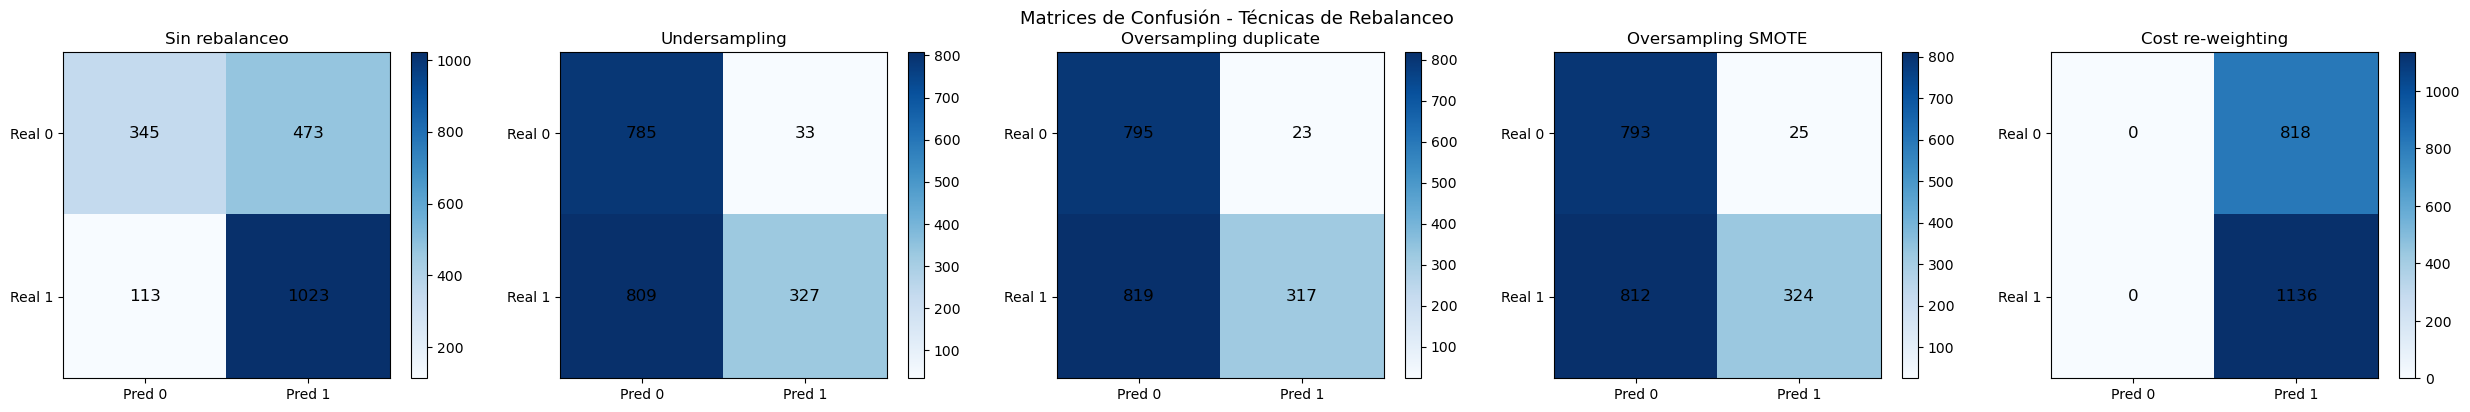

In [ ]:
#Matrices de confusion
modelos_preds = [
    ("Sin rebalanceo", y_pred_s),
    ("Undersampling", y_pred_u),
    ("Oversampling duplicate", y_pred_dup),
    ("Oversampling SMOTE", y_pred_smote),
    ("Cost re-weighting", y_pred_cr),
]
fig, axes = plt.subplots(1, 5, figsize=(25, 4))
for ax, (name, y_pred) in zip(axes, modelos_preds):
    utls.plot_confusion_matrix(y_true, y_pred, title=name, ax=ax)
plt.suptitle("Matrices de Confusión - Técnicas de Rebalanceo", fontsize=13)
plt.tight_layout()
plt.show()

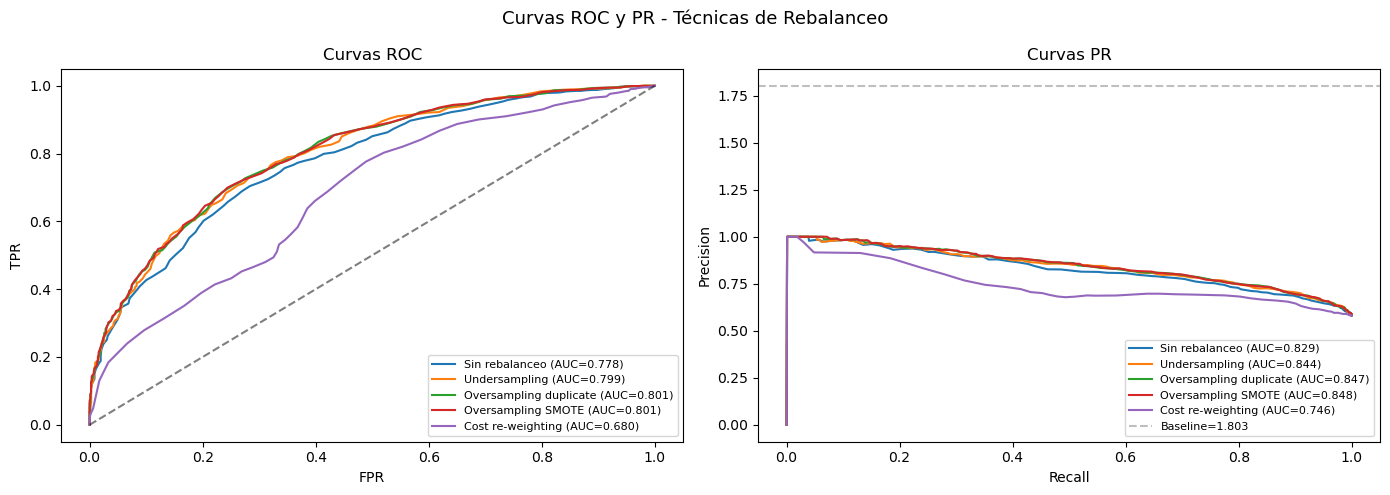

In [152]:
#Curvas ROC

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_probs = [
    ("Sin rebalanceo", y_prob_s),
    ("Undersampling", y_prob_u),
    ("Oversampling duplicate", y_prob_dup),
    ("Oversampling SMOTE", y_prob_smote),
    ("Cost re-weighting", y_prob_cr),
]

for name, y_prob in models_probs:
    fpr, tpr = mtr.roc_curve(y_true, y_prob)
    auc = mtr.auc(fpr, tpr)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

axes[0].plot([0,1], [0,1], 'k--', alpha=0.5)
axes[0].set_xlabel("FPR")
axes[0].set_ylabel("TPR")
axes[0].set_title("Curvas ROC")
axes[0].legend(fontsize=8)

for name, y_prob in models_probs:
    prec, rec = mtr.precision_recall_curve(y_true, y_prob)
    auc = mtr.auc(rec, prec)
    axes[1].plot(rec, prec, label=f"{name} (AUC={auc:.3f})")

baseline = y_true.mean()  
axes[1].axhline(baseline, linestyle='--', color='gray', 
                alpha=0.5, label=f"Baseline={baseline:.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Curvas PR")
axes[1].legend(fontsize=8)

plt.suptitle("Curvas ROC y PR - Técnicas de Rebalanceo", fontsize=13)
plt.tight_layout()
plt.show()